# Capstone Two — Data Wrangling

### Early prediction of quality-control failures from in-process sensor data (UCI SECOM)

This notebook takes the raw SECOM files and produces a modelling-ready dataset. It covers structural
cleaning, missing-value handling, and outlier treatment, in that order.

**Dataset.** 1,567 production units from a semiconductor wafer-fabrication line. Each unit carries
590 sensor measurements, a timestamp, and a pass/fail label from final in-house testing.
Failures are rare (~6.6%).

**Three constraints drive every decision below.**

1. **The data is a time series of production units, not an i.i.d. sample.** Units are ordered by
   test timestamp, and the downstream task (drift detection, early warning) is inherently temporal.
   All validation must therefore be time-ordered, which means the cleaning boundary is also temporal.

2. **No statistic may cross the validation boundary.** Column medians, outlier fences, and
   drop-lists are all *learned parameters*. Fitting them on the full dataset leaks information from
   the future into the training set and inflates every metric that follows. Everything below is fit
   on the training partition only and then applied to the held-out partition.

3. **Failures are rare, and the failure signal probably lives in the tails.** A sensor reading far
   from its normal operating range is exactly the kind of event that precedes a defect. So outliers
   here are treated as *suspect measurements to be bounded*, never as *rows to be deleted*. Deleting
   extreme rows in a 6.6%-positive problem is a fast way to delete the signal.

**Output artifacts.** A cleaned train/test pair, a JSON cleaning configuration that fully
reproduces the transform (so it can be re-fitted on PV production-line data with config changes
only), and a wrangling log recording every decision and its effect.

---
## 1. Setup

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 3.6), "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RAW_DIR = Path("../Dataset/secom")
OUT_DIR = Path("../Outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Cleaning hyperparameters (single place to retune for a new production line) ----
CFG = {
    "test_fraction":        0.20,   # chronological holdout, last 20% of units by timestamp
    "max_col_missing":      0.50,   # drop a sensor missing more than this share of readings
    "max_row_missing":      0.50,   # drop a unit missing more than this share of its sensors
    "near_constant_thresh": 0.995,  # drop a sensor whose modal value covers >= this share
    "corr_dup_thresh":      0.9999, # treat |r| above this as a duplicated sensor
    "missing_flag_thresh":  0.02,   # add a missing-indicator for sensors above this missing rate
    "winsor_lower_q":       0.005,  # robust clipping fences
    "winsor_upper_q":       0.995,
    "mad_z_thresh":         5.0,    # |robust z| above this counts as an outlier for reporting
}
CFG

{'test_fraction': 0.2,
 'max_col_missing': 0.5,
 'max_row_missing': 0.5,
 'near_constant_thresh': 0.995,
 'corr_dup_thresh': 0.9999,
 'missing_flag_thresh': 0.02,
 'winsor_lower_q': 0.005,
 'winsor_upper_q': 0.995,
 'mad_z_thresh': 5.0}

---
## 2. Load the raw files

`secom.data` is space-delimited with no header, `NaN` as the missing marker, and no index column.
`secom_labels.data` holds the label and a quoted `dd/mm/yyyy HH:MM:SS` timestamp. The label
encoding is `-1 = pass`, `1 = fail`; it is remapped to `0 / 1` so that the positive class is the
event of interest (a failure), which is what precision, recall, and PR-AUC will be computed against.

Sensors are given stable names `S000 … S589` matching their original column position, so any feature
found important later can be traced back to a physical measurement point.

In [2]:
X = pd.read_csv(RAW_DIR / "secom.data", sep=" ", header=None, na_values=["NaN"])
X.columns = [f"S{i:03d}" for i in range(X.shape[1])]

labels = pd.read_csv(RAW_DIR / "secom_labels.data", sep=" ", header=None,
                     names=["label", "timestamp"], quotechar='"')

y = (labels["label"] == 1).astype("int8").rename("fail")          # 1 = fail, 0 = pass
ts = pd.to_datetime(labels["timestamp"], format="%d/%m/%Y %H:%M:%S").rename("timestamp")

print(f"features : {X.shape[0]:,} units x {X.shape[1]} sensors")
print(f"labels   : {y.shape[0]:,}   dtypes: {set(X.dtypes.astype(str))}")
X.iloc[:5, :8]

features : 1,567 units x 590 sensors
labels   : 1,567   dtypes: {'float64'}


,S000,S001,S002,S003,S004,S005,S006,S007
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235


In [3]:
X.head()

,S000,S001,S002,S003,S004,S005,S006,S007,S008,S009,S010,S011,S012,S013,S014,S015,S016,S017,S018,S019,...,S570,S571,S572,S573,S574,S575,S576,S577,S578,S579,S580,S581,S582,S583,S584,S585,S586,S587,S588,S589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,...,533.8500,2.1113,8.95,0.3157,3.0624,0.1026,1.6765,14.9509,NaN,NaN,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,-0.0148,0.9627,200.5470,0.0,10.1548,414.7347,9.2599,0.9701,191.2872,12.4608,...,535.0164,2.4335,5.92,0.2653,2.0111,0.0772,1.1065,10.9003,0.0096,0.0201,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,0.0013,0.9615,202.0179,0.0,9.5157,416.7075,9.3144,0.9674,192.7035,12.5404,...,535.0245,2.0293,11.21,0.1882,4.0923,0.0640,2.0952,9.2721,0.0584,0.0484,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,-0.0033,0.9629,201.8482,0.0,9.6052,422.2894,9.6924,0.9687,192.1557,12.4782,...,530.5682,2.0253,9.33,0.1738,2.8971,0.0525,1.7585,8.5831,0.0202,0.0149,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,-0.0072,0.9569,201.9424,0.0,10.5661,420.5925,10.3387,0.9735,191.6037,12.4735,...,532.0155,2.0275,8.83,0.2224,3.1776,0.0706,1.6597,10.9698,NaN,NaN,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [4]:
X.head()


,S000,S001,S002,S003,S004,S005,S006,S007,S008,S009,S010,S011,S012,S013,S014,S015,S016,S017,S018,S019,...,S570,S571,S572,S573,S574,S575,S576,S577,S578,S579,S580,S581,S582,S583,S584,S585,S586,S587,S588,S589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,...,533.8500,2.1113,8.95,0.3157,3.0624,0.1026,1.6765,14.9509,NaN,NaN,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,-0.0148,0.9627,200.5470,0.0,10.1548,414.7347,9.2599,0.9701,191.2872,12.4608,...,535.0164,2.4335,5.92,0.2653,2.0111,0.0772,1.1065,10.9003,0.0096,0.0201,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,0.0013,0.9615,202.0179,0.0,9.5157,416.7075,9.3144,0.9674,192.7035,12.5404,...,535.0245,2.0293,11.21,0.1882,4.0923,0.0640,2.0952,9.2721,0.0584,0.0484,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,-0.0033,0.9629,201.8482,0.0,9.6052,422.2894,9.6924,0.9687,192.1557,12.4782,...,530.5682,2.0253,9.33,0.1738,2.8971,0.0525,1.7585,8.5831,0.0202,0.0149,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,-0.0072,0.9569,201.9424,0.0,10.5661,420.5925,10.3387,0.9735,191.6037,12.4735,...,532.0155,2.0275,8.83,0.2224,3.1776,0.0706,1.6597,10.9698,NaN,NaN,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [52]:
# Assemble one frame indexed by time-order rank, keeping timestamp and label as columns.
df = X.copy()
df.insert(0, "timestamp", ts)
df.insert(1, "fail", y)

# Sort chronologically and record the original file row so nothing becomes untraceable.
df["source_row"] = np.arange(len(df))
df = df.sort_values("timestamp", kind="stable") .reset_index(drop=True)

SENSORS = [col for col in df.columns if col.startswith("S")]
print(f"already chronological in the raw file: {ts.is_monotonic_increasing}")
print(f"time span: {df.timestamp.min()}  ->  {df.timestamp.max()}  "
      f"({(df.timestamp.max() - df.timestamp.min()).days} days)")
df[["timestamp", "fail", "source_row"]].head()

already chronological in the raw file: True
time span: 2008-07-19 11:55:00  ->  2008-10-17 06:07:00  (89 days)


,timestamp,fail,source_row
0,2008-07-19 11:55:00,0,0
1,2008-07-19 12:32:00,0,1
2,2008-07-19 13:17:00,1,2
3,2008-07-19 14:43:00,0,3
4,2008-07-19 15:22:00,0,4


---
## 3. Structural audit

Before changing anything, establish what is actually in the file: the class balance, whether the
failure rate is stable over the collection window, and whether there are duplicate units.

The stability check matters more than it looks. If the failure rate drifts substantially across the
three months, a chronological holdout will have a different base rate than the training data, and
that has to be known up front rather than discovered as a mysterious performance drop later.

In [53]:
n, k = len(df), len(SENSORS)
n_fail = int(df.fail.sum())
print(f"units            : {n:,}")
print(f"sensors          : {k}")
print(f"failures         : {n_fail}  ({n_fail / n:.2%})")
print(f"pass:fail ratio  : {(n - n_fail) / n_fail:.1f} : 1")
print(f"exact duplicate sensor-vector rows : {df.duplicated(subset=SENSORS).sum()}")
print(f"duplicate timestamps               : {df.timestamp.duplicated().sum()}")

units            : 1,567
sensors          : 590
failures         : 104  (6.64%)
pass:fail ratio  : 14.1 : 1
exact duplicate sensor-vector rows : 0
duplicate timestamps               : 33


exact duplicate sensor-vector rows : 0
duplicate timestamps               : 33


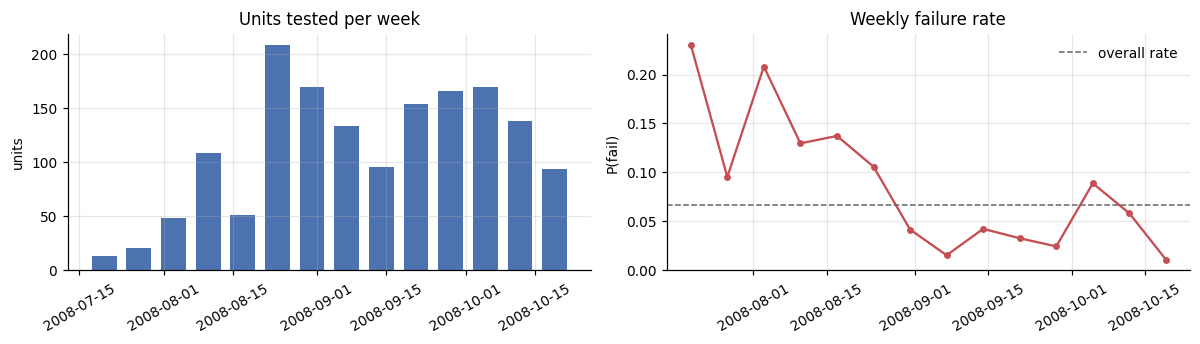

weekly failure rate: mean 0.087  sd 0.070  range [0.011, 0.231]


In [8]:
# Failure rate by week - is the base rate stable enough for a chronological split?
weekly = (df.set_index("timestamp")
            .resample("W")["fail"]
            .agg(["size", "sum"])
            .rename(columns={"size": "units", "sum": "fails"}))
weekly["fail_rate"] = weekly.fails / weekly.units.replace(0, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].bar(weekly.index, weekly.units, width=5, color="#4C72B0")
ax[0].set_title("Units tested per week"); ax[0].set_ylabel("units")
ax[1].plot(weekly.index, weekly.fail_rate, marker="o", ms=3.5, color="#C44E52")
ax[1].axhline(df.fail.mean(), ls="--", lw=1, color="0.4", label="overall rate")
ax[1].set_title("Weekly failure rate"); ax[1].set_ylabel("P(fail)"); ax[1].legend(frameon=False)
for a in ax: a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print(f"weekly failure rate: mean {weekly.fail_rate.mean():.3f}  "
      f"sd {weekly.fail_rate.std():.3f}  range [{weekly.fail_rate.min():.3f}, {weekly.fail_rate.max():.3f}]")

Production volume is uneven across the window and the weekly failure rate is noisy on small weekly
counts, but there is no monotone trend that would make the final 20% of units structurally
different from the rest. A chronological split is sound.

---
## 4. Missingness audit

Two questions, and they get different treatments:

- **How much is missing, and where?** Determines what gets dropped and what gets imputed.
- **Is the missingness itself informative?** A sensor that goes dark on a specific tool, recipe, or
  shift is not missing at random — the *fact* of the gap can carry as much signal as the value. If
  so, imputing silently destroys that signal, and the fix is to keep a missing-indicator column.

Both are computed on the full dataset here for description only. The actual drop and impute
decisions in §6–§8 are re-derived from the training partition alone.

In [9]:
col_missing = df[SENSORS].isna().mean().sort_values(ascending=False)
row_missing = df[SENSORS].isna().mean(axis=1)

print("Sensor-level missing rate")
print(col_missing.describe().round(4).to_string())
print()
for t in [0.0, 0.01, 0.05, 0.20, 0.50, 0.90]:
    print(f"  sensors with > {t:>4.0%} missing : {(col_missing > t).sum():>3}")
print(f"\n  sensors with zero missing      : {(col_missing == 0).sum()}")
print(f"\nUnit-level missing rate: max {row_missing.max():.2%}, "
      f"mean {row_missing.mean():.2%}, units above {CFG['max_row_missing']:.0%}: "
      f"{(row_missing > CFG['max_row_missing']).sum()}")

Sensor-level missing rate
count    590.0000
mean       0.0454
std        0.1543
min        0.0000
25%        0.0013
50%        0.0038
75%        0.0057
max        0.9119

  sensors with >   0% missing : 538
  sensors with >   1% missing : 103
  sensors with >   5% missing :  52
  sensors with >  20% missing :  32
  sensors with >  50% missing :  28
  sensors with >  90% missing :   4

  sensors with zero missing      : 52

Unit-level missing rate: max 25.76%, mean 4.54%, units above 50%: 0


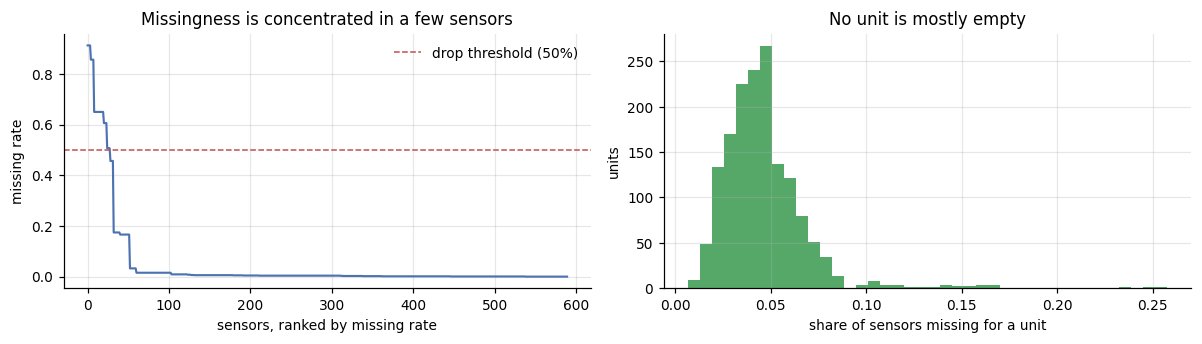

,missing_rate
S292,91.2%
S293,91.2%
S158,91.2%
S157,91.2%
S492,85.6%
S085,85.6%
S358,85.6%
S220,85.6%
S244,65.0%
S517,65.0%


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(np.arange(len(col_missing)), col_missing.values, lw=1.4, color="#4C72B0")
ax[0].axhline(CFG["max_col_missing"], ls="--", lw=1, color="#C44E52",
              label=f"drop threshold ({CFG['max_col_missing']:.0%})")
ax[0].set_xlabel("sensors, ranked by missing rate"); ax[0].set_ylabel("missing rate")
ax[0].set_title("Missingness is concentrated in a few sensors"); ax[0].legend(frameon=False)

ax[1].hist(row_missing, bins=40, color="#55A868")
ax[1].set_xlabel("share of sensors missing for a unit"); ax[1].set_ylabel("units")
ax[1].set_title("No unit is mostly empty")
plt.tight_layout(); plt.show()

col_missing.head(10).to_frame("missing_rate").style.format("{:.1%}")

The shape is the useful finding: a small tail of sensors is missing for most units, while the great
majority are missing for well under 1% of units. So the problem splits cleanly — drop the tail,
impute the rest. No unit is missing more than ~26% of its sensors, so nothing needs to be dropped at
the row level; the row threshold stays in the config for reuse on a future dataset that may need it.

In [11]:
# Is missingness informative? Chi-square test of missing-indicator vs. the fail label,
# with Benjamini-Hochberg FDR control across the sensors actually worth testing.
testable = col_missing[(col_missing > 0.01) & (col_missing < 0.99)].index.tolist()

rows = []
for s in testable:
    m = df[s].isna().values
    tab = pd.crosstab(m, df.fail.values)
    if tab.shape == (2, 2) and tab.values.min() >= 1:
        chi2, p, _, _ = stats.chi2_contingency(tab)
        rows.append({"sensor": s,
                     "missing_rate": m.mean(),
                     "fail_rate_when_present": df.fail[~m].mean(),
                     "fail_rate_when_missing": df.fail[m].mean(),
                     "p_value": p})

miss_assoc = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
if len(miss_assoc):
    m_ = len(miss_assoc)
    miss_assoc["p_bh"] = np.minimum.accumulate(
        (miss_assoc.p_value * m_ / np.arange(1, m_ + 1))[::-1])[::-1].clip(0, 1)
    n_sig = int((miss_assoc.p_bh < 0.05).sum())
    print(f"tested {m_} sensors | significant at BH-FDR 5%: {n_sig}")
    display(miss_assoc.head(8).style.format({
        "missing_rate": "{:.1%}", "fail_rate_when_present": "{:.1%}",
        "fail_rate_when_missing": "{:.1%}", "p_value": "{:.3g}", "p_bh": "{:.3g}"}))

tested 60 sensors | significant at BH-FDR 5%: 8


,sensor,missing_rate,fail_rate_when_present,fail_rate_when_missing,p_value,p_bh
0,S073,50.7%,8.8%,4.5%,0.00101,0.0151
1,S345,50.7%,8.8%,4.5%,0.00101,0.0151
2,S072,50.7%,8.8%,4.5%,0.00101,0.0151
3,S346,50.7%,8.8%,4.5%,0.00101,0.0151
4,S519,45.6%,8.3%,4.6%,0.00447,0.0335
5,S247,45.6%,8.3%,4.6%,0.00447,0.0335
6,S385,45.6%,8.3%,4.6%,0.00447,0.0335
7,S112,45.6%,8.3%,4.6%,0.00447,0.0335


Whatever the test returns, the decision is the same and it is deliberately conservative: for any
sensor missing more than 2% of the time, keep a binary `<sensor>_isna` indicator alongside the
imputed value. If the gap pattern is informative the model can use it; if it is not, the indicator
is a near-constant column that regularisation and the feature-selection stage will discard. The
asymmetry favours keeping it — a discarded useless flag costs nothing, a destroyed signal cannot be
recovered downstream.

---
## 5. Degenerate sensors

Three failure modes make a column useless before any modelling:

- **Constant** — one distinct value across every unit. Zero variance, zero information.
- **Near-constant** — a single modal value covering ≥99.5% of units. With 104 failures total, a
  column whose variation touches under 8 units cannot support a reliable estimate; it will
  contribute noise or produce a spurious split.
- **Duplicated** — two sensors correlated at |r| > 0.9999. These are recording the same physical
  quantity twice (or one is a rescaling of the other). Keeping both distorts correlation-based
  feature selection and destabilises any linear model.

Constant and near-constant are structural properties of the column and can be identified now.
Duplicate detection is deferred to §7, where it is computed on training rows only — the correlation
between two columns is a statistic, and statistics stay on the training side of the boundary.

In [12]:
nunique = df[SENSORS].nunique(dropna=True)
modal_share = df[SENSORS].apply(lambda s: s.value_counts(normalize=True, dropna=True).max()
                                if s.notna().any() else 1.0)

all_missing  = [s for s in SENSORS if col_missing[s] == 1.0]
constant     = [s for s in SENSORS if nunique[s] <= 1 and s not in all_missing]
near_const   = [s for s in SENSORS if s not in all_missing and s not in constant
                and modal_share[s] >= CFG["near_constant_thresh"]]

print(f"all-missing sensors  : {len(all_missing)}")
print(f"constant sensors     : {len(constant)}")
print(f"near-constant (>={CFG['near_constant_thresh']:.1%} modal) : {len(near_const)}")
print(f"informative so far   : {len(SENSORS) - len(all_missing) - len(constant) - len(near_const)}")

pd.DataFrame({"n_unique": nunique, "modal_share": modal_share, "missing": col_missing}) \
  .loc[constant[:5] + near_const[:5]].round(4)

all-missing sensors  : 0
constant sensors     : 116
near-constant (>=99.5% modal) : 6
informative so far   : 468


,n_unique,modal_share,missing
S005,1,1.0000,0.0089
S013,1,1.0000,0.0019
S042,1,1.0000,0.0006
S049,1,1.0000,0.0006
S052,1,1.0000,0.0006
S074,2,0.9994,0.0038
S206,2,0.9994,0.0038
S209,2,0.9994,0.0038
S342,2,0.9994,0.0038
S347,2,0.9994,0.0038


---
## 6. Chronological train / test split

**This is the leakage boundary, and it is placed before any statistic is computed.**

The split is by time, not at random. A random split would let the model train on units produced
after the ones it is tested on, which is impossible in deployment: the model has to score unit *t*
knowing only units *< t*. A randomly-split score on this dataset would be optimistic for reasons
that have nothing to do with the model's actual ability to warn an operator.

Everything from here on — drop lists, medians, outlier fences — is derived from `train` and merely
*applied* to `test`.

In [13]:
split_idx = int(len(df) * (1 - CFG["test_fraction"]))
split_time = df.timestamp.iloc[split_idx]

train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

summary = pd.DataFrame({
    "units":     [len(train), len(test)],
    "failures":  [int(train.fail.sum()), int(test.fail.sum())],
    "fail_rate": [train.fail.mean(), test.fail.mean()],
    "start":     [train.timestamp.min(), test.timestamp.min()],
    "end":       [train.timestamp.max(), test.timestamp.max()],
}, index=["train", "test"])

print(f"boundary: {split_time}\n")
display(summary.style.format({"fail_rate": "{:.2%}"}))
print("No timestamp overlap:", train.timestamp.max() < test.timestamp.min())

boundary: 2008-10-02 20:54:00



,units,failures,fail_rate,start,end
train,1253,87,6.94%,2008-07-19 11:55:00,2008-10-02 19:25:00
test,314,17,5.41%,2008-10-02 20:54:00,2008-10-17 06:07:00


No timestamp overlap: True


The two partitions have similar but not identical failure rates — expected from ~20 failures in the
holdout, where sampling noise on the base rate is large. It is worth noting now: a holdout this
small makes single-run test metrics unstable, so model selection should lean on time-ordered
cross-validation over the training partition, with this holdout reserved for a final check.

---
## 7. Building the drop list (fit on train)

Re-deriving all four rules on the training partition. `S###` names that appear here would be
carried into a production pipeline as a fixed list; on a new line the same rules are re-fit rather
than the same names reused.

In [14]:
tr_missing = train[SENSORS].isna().mean()
tr_nunique = train[SENSORS].nunique(dropna=True)
tr_modal   = train[SENSORS].apply(lambda s: s.value_counts(normalize=True, dropna=True).max()
                                  if s.notna().any() else 1.0)

drop_missing   = tr_missing[tr_missing > CFG["max_col_missing"]].index.tolist()
drop_constant  = [s for s in SENSORS if tr_nunique[s] <= 1 and s not in drop_missing]
drop_nearconst = [s for s in SENSORS
                  if s not in drop_missing and s not in drop_constant
                  and tr_modal[s] >= CFG["near_constant_thresh"]]

kept = [s for s in SENSORS if s not in set(drop_missing + drop_constant + drop_nearconst)]
print(f"drop - too much missing (> {CFG['max_col_missing']:.0%}) : {len(drop_missing)}")
print(f"drop - constant on train                    : {len(drop_constant)}")
print(f"drop - near-constant on train               : {len(drop_nearconst)}")
print(f"surviving into duplicate check              : {len(kept)}")

drop - too much missing (> 50%) : 24
drop - constant on train                    : 122
drop - near-constant on train               : 0
surviving into duplicate check              : 444


In [15]:
# Duplicate / perfectly-collinear sensors, on train rows only.
# Median-fill first purely so pairwise correlation is computed on aligned, complete vectors.
tmp = train[kept].fillna(train[kept].median())
corr = np.corrcoef(tmp.values, rowvar=False)
np.fill_diagonal(corr, 0.0)
corr = np.nan_to_num(corr)

drop_duplicate, pairs = set(), []
upper = np.triu_indices_from(corr, k=1)
for i, j in zip(*upper):
    if abs(corr[i, j]) > CFG["corr_dup_thresh"]:
        a, b = kept[i], kept[j]
        if a not in drop_duplicate and b not in drop_duplicate:
            drop_duplicate.add(b)                       # keep the earlier-indexed sensor
            pairs.append((a, b, round(float(corr[i, j]), 6)))

drop_duplicate = sorted(drop_duplicate)
print(f"duplicate sensors dropped (|r| > {CFG['corr_dup_thresh']}): {len(drop_duplicate)}")
if pairs:
    display(pd.DataFrame(pairs[:8], columns=["kept", "dropped", "r"]))

FEATURES = [s for s in kept if s not in set(drop_duplicate)]
print(f"\nsensors retained: {len(FEATURES)} of {len(SENSORS)} "
      f"({len(FEATURES) / len(SENSORS):.1%})")

duplicate sensors dropped (|r| > 0.9999): 8


,kept,dropped,r
0,S034,S036,-1.000000
1,S152,S287,0.999997
2,S172,S174,1.000000
3,S249,S387,0.999935
4,S251,S389,0.999946
5,S252,S390,0.999992
6,S307,S309,0.999999
7,S583,S585,0.999905



sensors retained: 436 of 590 (73.9%)


---
## 8. Missing-value treatment

**Median, not mean.** Sensor distributions here are heavy-tailed and skewed; the mean of a column
with a few extreme readings sits nowhere near its typical value, so mean-imputation would pull
imputed units toward a value no real unit exhibits. The median is unaffected by the tails.

**Medians come from train.** Applied unchanged to test. This is the concrete form the leakage rule
takes: a test unit's gap is filled with a value derived only from units produced before it.

**Indicators before imputation.** The `_isna` flags are computed first, since imputation erases the
information they encode.

A model-based imputer (iterative / kNN) is a reasonable alternative and could be compared later, but
it is a fitted model in its own right — one more thing to fit inside the CV loop, one more source of
leakage if handled carelessly. Median imputation is the right starting point given that most
retained sensors are missing for well under 1% of units, where the choice of imputer barely matters.

In [16]:
flag_cols = [s for s in FEATURES if tr_missing[s] > CFG["missing_flag_thresh"]]
medians = train[FEATURES].median()

def add_flags_and_impute(frame):
    out = frame.copy()
    for s in flag_cols:
        out[f"{s}_isna"] = out[s].isna().astype("int8")
    out[FEATURES] = out[FEATURES].fillna(medians)
    return out

train_i = add_flags_and_impute(train)
test_i  = add_flags_and_impute(test)

print(f"missing-indicator columns added: {len(flag_cols)}  "
      f"(sensors missing > {CFG['missing_flag_thresh']:.0%} on train)")
print(f"remaining NaNs - train: {int(train_i[FEATURES].isna().sum().sum())}, "
      f"test: {int(test_i[FEATURES].isna().sum().sum())}")
if flag_cols:
    display(pd.DataFrame({"train_missing_rate": tr_missing[flag_cols]})
            .sort_values("train_missing_rate", ascending=False)
            .head(8).style.format("{:.1%}"))

missing-indicator columns added: 28  (sensors missing > 2% on train)
remaining NaNs - train: 0, test: 0


,train_missing_rate
S072,45.8%
S073,45.8%
S346,45.8%
S345,45.8%
S247,33.7%
S112,33.7%
S385,33.7%
S519,33.7%


In [17]:
# Sanity check: imputation must not shift the retained sensors' central tendency or spread.
# Differences are expressed in units of each sensor's own pre-imputation SD, so they are comparable
# across sensors measured on wildly different scales.
before = train[FEATURES].describe().T[["mean", "50%", "std"]]
after  = train_i[FEATURES].describe().T[["mean", "50%", "std"]]
sd     = before["std"].replace(0, np.nan)
shift  = (after - before).abs().div(sd, axis=0).dropna(how="all")

print("Post-imputation shift in train, in units of each sensor's own SD:")
print(shift.describe().loc[["mean", "50%", "max"]].round(4).to_string())
print(f"\nsensors whose mean moved > 0.10 SD : {(shift['mean'] > 0.10).sum()}")
print(f"sensors whose SD  moved > 0.10 SD : {(shift['std'] > 0.10).sum()}")
display(shift.sort_values("mean", ascending=False).head(5).round(4))

Post-imputation shift in train, in units of each sensor's own SD:
        mean  50%     std
mean  0.0041  0.0  0.0097
50%   0.0001  0.0  0.0006
max   0.1331  0.0  0.2623

sensors whose mean moved > 0.10 SD : 3
sensors whose SD  moved > 0.10 SD : 26


,mean,50%,std
S247,0.1331,0.0,0.1646
S519,0.1257,0.0,0.1669
S385,0.1098,0.0,0.1713
S548,0.0962,0.0,0.0875
S564,0.0892,0.0,0.0992


---
## 9. Outlier treatment

**Detection.** The classic z-score is useless here, because it is built from the mean and standard
deviation — both of which are themselves dragged by the outliers being looked for. A single extreme
reading inflates the SD enough to hide itself. So detection uses the **robust z-score**, built on
the median and the median absolute deviation:

$$z_{\text{robust}} = \frac{x - \text{median}(x)}{1.4826 \cdot \text{MAD}(x)}$$

The 1.4826 factor makes the scaled MAD a consistent estimator of σ for Gaussian data, so the
threshold keeps its familiar interpretation. Its breakdown point is 50%: it stays reliable until
half the data is contaminated.

**Treatment: winsorize, never delete.** Two reasons, and the second is the important one.

1. Some extremes are sensor faults, but many are real process excursions.
2. **Extreme readings are disproportionately likely to be the failures.** With 104 positives in
   total, trimming rows on an outlier rule risks removing the very units the model exists to
   predict — silently, and in a way that looks like a cleaner dataset.

So no rows are removed. Values are clipped to train-derived percentile fences, which bounds the
leverage a wild reading can exert on a model without discarding the unit or erasing the fact that
its reading was extreme.

In [18]:
# --- Detection: robust z-scores on the training partition ---
med = train_i[FEATURES].median()
mad = (train_i[FEATURES] - med).abs().median() * 1.4826
mad_safe = mad.replace(0, np.nan)                   # MAD == 0 => no robust scale; skip the sensor

rz = (train_i[FEATURES] - med) / mad_safe
outlier_rate = (rz.abs() > CFG["mad_z_thresh"]).mean().sort_values(ascending=False)
n_scaleless = int(mad_safe.isna().sum())

print(f"sensors with MAD = 0 (no robust scale, detection skipped): {n_scaleless}")
print(f"share of all cells flagged as outliers: "
      f"{(rz.abs() > CFG['mad_z_thresh']).sum().sum() / rz.notna().sum().sum():.2%}")
print(f"sensors with > 5% of readings flagged : {(outlier_rate > 0.05).sum()}\n")
display(outlier_rate.head(8).to_frame("flagged_share").style.format("{:.1%}"))

sensors with MAD = 0 (no robust scale, detection skipped): 10
share of all cells flagged as outliers: 2.04%
sensors with > 5% of readings flagged : 43



,flagged_share
S027,28.6%
S025,28.6%
S345,27.9%
S072,25.5%
S031,25.1%
S562,21.9%
S073,21.1%
S346,21.0%


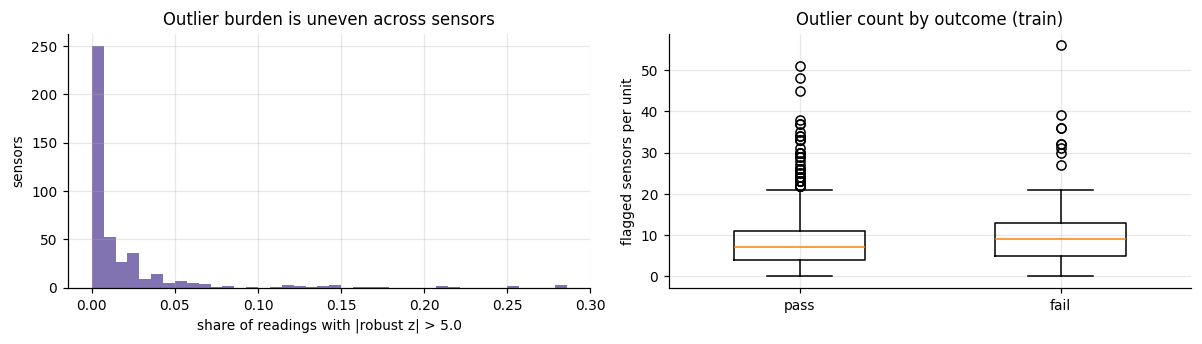

       mean  median
fail               
0      8.49     7.0
1     11.49     9.0

Mann-Whitney U on flagged-sensor count, fail vs pass: p = 0.0059


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(outlier_rate.dropna(), bins=40, color="#8172B2")
ax[0].set_xlabel(f"share of readings with |robust z| > {CFG['mad_z_thresh']}")
ax[0].set_ylabel("sensors"); ax[0].set_title("Outlier burden is uneven across sensors")

# Are flagged readings associated with failure? Compare mean flag count by outcome.
flags_per_unit = (rz.abs() > CFG["mad_z_thresh"]).sum(axis=1)
ax[1].boxplot([flags_per_unit[train_i.fail == 0], flags_per_unit[train_i.fail == 1]],
              tick_labels=["pass", "fail"], widths=0.5)
ax[1].set_ylabel("flagged sensors per unit"); ax[1].set_title("Outlier count by outcome (train)")
plt.tight_layout(); plt.show()

grp = flags_per_unit.groupby(train_i.fail).agg(["mean", "median"])
u, p = stats.mannwhitneyu(flags_per_unit[train_i.fail == 1],
                          flags_per_unit[train_i.fail == 0], alternative="two-sided")
print(grp.round(2).to_string())
print(f"\nMann-Whitney U on flagged-sensor count, fail vs pass: p = {p:.4f}")

The right-hand panel is the empirical justification for not deleting outlier rows: it shows directly
whether failing units carry more extreme readings than passing ones. Where they do, an outlier
*count* is itself a candidate feature — which is why the flag count is retained below as
`n_outlier_flags` rather than being thrown away after use.

In [20]:
# --- Treatment: winsorize at train-derived percentile fences ---
lo = train_i[FEATURES].quantile(CFG["winsor_lower_q"])
hi = train_i[FEATURES].quantile(CFG["winsor_upper_q"])
degenerate = (hi <= lo)                             # no spread: leave the sensor untouched
lo, hi = lo.mask(degenerate, -np.inf), hi.mask(degenerate, np.inf)
print(f"sensors skipped for zero spread between fences: {int(degenerate.sum())}")

def winsorize(frame):
    out = frame.copy()
    out["n_outlier_flags"] = (((out[FEATURES] - med) / mad_safe).abs()
                              > CFG["mad_z_thresh"]).sum(axis=1).astype("int16")
    out[FEATURES] = out[FEATURES].clip(lower=lo, upper=hi, axis=1)
    return out

train_c, test_c = winsorize(train_i), winsorize(test_i)

for name, raw, clean in [("train", train_i, train_c), ("test", test_i, test_c)]:
    n_clipped = (raw[FEATURES].values != clean[FEATURES].values).sum()
    print(f"{name}: {n_clipped:,} values clipped "
          f"({n_clipped / raw[FEATURES].size:.2%} of cells)")

sensors skipped for zero spread between fences: 0
train: 5,382 values clipped (0.99% of cells)
test: 2,325 values clipped (1.70% of cells)


train: 5,382 values clipped (0.99% of cells)
test: 2,325 values clipped (1.70% of cells)


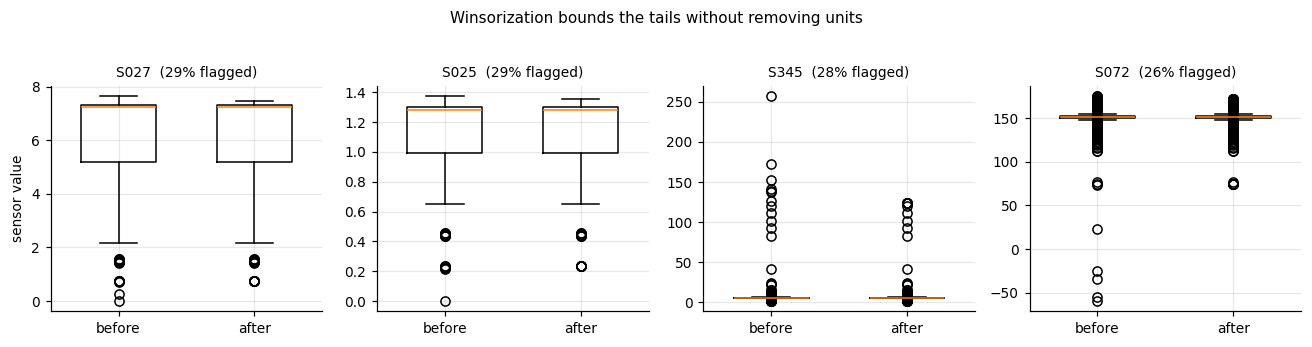

units in train before / after outlier handling: 1253 / 1253
failures in train before / after              : 87 / 87


In [21]:
# Visual check on the four worst-affected sensors: distribution before vs after clipping.
worst = outlier_rate.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, s in zip(axes, worst):
    ax.boxplot([train_i[s].values, train_c[s].values],
               tick_labels=["before", "after"], widths=0.55)
    ax.set_title(f"{s}  ({outlier_rate[s]:.0%} flagged)", fontsize=9)
axes[0].set_ylabel("sensor value")
plt.suptitle("Winsorization bounds the tails without removing units", y=1.03, fontsize=10)
plt.tight_layout(); plt.show()

print(f"units in train before / after outlier handling: {len(train_i)} / {len(train_c)}")
print(f"failures in train before / after              : {int(train_i.fail.sum())} / {int(train_c.fail.sum())}")

Row counts and failure counts are identical before and after, which is the property being enforced:
the tails are bounded, no unit is lost, and the class balance is untouched.

**Scaling is deliberately not applied here.** Sensors span wildly different units and magnitudes, so
standardisation will be needed for any distance- or gradient-based model — but it belongs inside the
modelling pipeline, fit per-fold, not baked into a saved dataset. Doing it here would push a
train-fold statistic into every future validation fold.

---
## 10. Final validation

A cleaned dataset is only useful if its guarantees are checked rather than assumed. Each assertion
below encodes one contract that downstream modelling code will rely on.

In [22]:
MODEL_COLS = FEATURES + [f"{s}_isna" for s in flag_cols] + ["n_outlier_flags"]

checks = {
    "no missing values in train":      int(train_c[MODEL_COLS].isna().sum().sum()) == 0,
    "no missing values in test":       int(test_c[MODEL_COLS].isna().sum().sum()) == 0,
    "no infinities":                   bool(np.isfinite(train_c[MODEL_COLS].to_numpy(float)).all()
                                            and np.isfinite(test_c[MODEL_COLS].to_numpy(float)).all()),
    "no constant sensors in train":    int((train_c[FEATURES].nunique() <= 1).sum()) == 0,
    "identical columns train/test":    list(train_c[MODEL_COLS].columns) == list(test_c[MODEL_COLS].columns),
    "no unit lost":                    len(train_c) + len(test_c) == len(df),
    "no failure lost":                 int(train_c.fail.sum() + test_c.fail.sum()) == n_fail,
    "train strictly precedes test":    train_c.timestamp.max() < test_c.timestamp.min(),
    "train chronologically ordered":   train_c.timestamp.is_monotonic_increasing,
    "labels binary 0/1":               set(pd.concat([train_c.fail, test_c.fail]).unique()) <= {0, 1},
}
for name, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
assert all(checks.values()), "cleaning contract violated"

print(f"\nmodelling matrix: {len(MODEL_COLS)} columns "
      f"({len(FEATURES)} sensors + {len(flag_cols)} missing flags + 1 outlier count)")

  [PASS] no missing values in train
  [PASS] no missing values in test
  [PASS] no infinities
  [PASS] no constant sensors in train
  [PASS] identical columns train/test
  [PASS] no unit lost
  [PASS] no failure lost
  [PASS] train strictly precedes test
  [PASS] train chronologically ordered
  [PASS] labels binary 0/1

modelling matrix: 465 columns (436 sensors + 28 missing flags + 1 outlier count)


In [23]:
train_c[MODEL_COLS].describe().T.head(8).round(3)

,count,mean,std,min,25%,50%,75%,max
S000,1253.0,3014.389,68.137,2830.378,2967.540,3012.090,3057.310,3232.006
S001,1253.0,2495.180,80.604,2238.932,2452.100,2498.840,2539.470,2738.270
S002,1253.0,2200.272,30.621,2074.289,2179.200,2200.133,2220.044,2276.456
S003,1253.0,1384.457,380.416,861.804,1072.806,1288.086,1622.351,2490.695
S004,1253.0,1.295,0.367,0.722,1.018,1.298,1.483,3.502
S006,1253.0,101.115,4.846,85.428,98.937,101.833,104.307,111.549
S007,1253.0,0.122,0.002,0.117,0.121,0.122,0.124,0.128
S008,1253.0,1.471,0.068,1.311,1.421,1.468,1.521,1.637


---
## 11. Persist artifacts

Three things are written, not one. The cleaned data is the least interesting of them.

The **cleaning config** is the real deliverable: every learned parameter — drop lists, medians,
fences, the split boundary — serialised so the exact transform can be replayed on new units, and so
the proposal's requirement that the pipeline "be re-fitted on PV-line data with configuration
changes only" is actually met rather than asserted.

The **wrangling log** records what each step cost in columns and cells, which is what a reader of the
report needs to judge whether the cleaning was reasonable.

In [24]:
train_out = train_c[["timestamp", "fail", "source_row"] + MODEL_COLS]
test_out  = test_c[["timestamp", "fail", "source_row"] + MODEL_COLS]

train_out.to_csv(OUT_DIR / "secom_clean_train.csv", index=False)
test_out.to_csv(OUT_DIR / "secom_clean_test.csv", index=False)
try:
    train_out.to_parquet(OUT_DIR / "secom_clean_train.parquet", index=False)
    test_out.to_parquet(OUT_DIR / "secom_clean_test.parquet", index=False)
    print("wrote CSV + Parquet")
except Exception as e:
    print(f"CSV written; Parquet skipped ({type(e).__name__})")

cleaning_config = {
    "created": pd.Timestamp.now().isoformat(timespec="seconds"),
    "source": "UCI SECOM",
    "hyperparameters": CFG,
    "split": {"boundary_timestamp": str(split_time),
              "n_train": len(train_out), "n_test": len(test_out)},
    "dropped": {"too_much_missing": drop_missing, "constant": drop_constant,
                "near_constant": drop_nearconst, "duplicate": drop_duplicate},
    "features_retained": FEATURES,
    "missing_flag_sensors": flag_cols,
    "imputation": {"strategy": "median", "fit_on": "train",
                   "values": {k: float(v) for k, v in medians.items()}},
    "winsorization": {"lower": {k: (None if not np.isfinite(v) else float(v)) for k, v in lo.items()},
                      "upper": {k: (None if not np.isfinite(v) else float(v)) for k, v in hi.items()}},
    "robust_scale": {"median": {k: float(v) for k, v in med.items()},
                     "mad_scaled": {k: (None if pd.isna(v) else float(v)) for k, v in mad_safe.items()}},
}
(OUT_DIR / "cleaning_config.json").write_text(json.dumps(cleaning_config, indent=2))
print(f"cleaning_config.json: {(OUT_DIR / 'cleaning_config.json').stat().st_size / 1024:.0f} KB")

wrote CSV + Parquet
cleaning_config.json: 67 KB


In [25]:
log = pd.DataFrame([
    ("0. raw",                          len(SENSORS), f"{df[SENSORS].isna().sum().sum():,} missing cells"),
    (f"1. drop missing > {CFG['max_col_missing']:.0%}",
                                        -len(drop_missing), "sensors offline for most units"),
    ("2. drop constant",                -len(drop_constant), "zero variance on train"),
    (f"3. drop near-constant >= {CFG['near_constant_thresh']:.1%}",
                                        -len(drop_nearconst), "too few varying units to estimate"),
    (f"4. drop duplicates |r| > {CFG['corr_dup_thresh']}",
                                        -len(drop_duplicate), "same physical measurement"),
    ("5. median impute (train-fit)",    0, "0 missing values remain"),
    ("6. add missing indicators",       +len(flag_cols), "preserves informative gaps"),
    ("7. winsorize + outlier count",    +1, "no rows removed, tails bounded"),
], columns=["step", "column_delta", "note"])
log["running_total"] = log.column_delta.cumsum()

(OUT_DIR / "wrangling_log.md").write_text(
    "# SECOM data wrangling log\n\n" + log.to_markdown(index=False) +
    f"\n\nFinal modelling matrix: {len(train_out)} train + {len(test_out)} test units "
    f"x {len(MODEL_COLS)} columns.\n"
    f"Split boundary: {split_time}. Failure rate: "
    f"{train_out.fail.mean():.2%} train / {test_out.fail.mean():.2%} test.\n")

display(log)
print(f"\nfiles in {OUT_DIR}:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name:32s} {f.stat().st_size / 1024:8.1f} KB")

,step,column_delta,note,running_total
0,0. raw,590,"41,951 missing cells",590
1,1. drop missing > 50%,-24,sensors offline for most units,566
2,2. drop constant,-122,zero variance on train,444
3,3. drop near-constant >= 99.5%,0,too few varying units to estimate,444
4,4. drop duplicates |r| > 0.9999,-8,same physical measurement,436
5,5. median impute (train-fit),0,0 missing values remain,436
6,6. add missing indicators,28,preserves informative gaps,464
7,7. winsorize + outlier count,1,"no rows removed, tails bounded",465



files in ..\Outputs:
  cleaning_config.json                 66.9 KB
  secom_clean_test.csv                985.0 KB
  secom_clean_test.parquet            981.3 KB
  secom_clean_train.csv              3919.9 KB
  secom_clean_train.parquet          2801.5 KB
  wrangling_log.md                      1.2 KB


---
## 12. Summary and what follows

**What was done.** The 590 raw sensors were reduced to a retained set by dropping columns that were
mostly missing, constant, near-constant, or duplicated. Remaining gaps were median-imputed using
training-partition medians, with binary indicators kept for any sensor missing more than 2% of
readings so that informative gaps survive. Extreme values were bounded by winsorization at
train-derived percentile fences, and the per-unit count of flagged readings was kept as a feature.
Every unit and every failure was preserved.

**What the data now guarantees.** No missing values, no infinities, no zero-variance columns,
identical schema across train and test, a strict temporal boundary between the two, and a serialised
config that reproduces the whole transform.

**Deliberate omissions, and why.**

| Not done here | Reason |
|---|---|
| Feature scaling | Fit per-fold inside the modelling pipeline; baking it in leaks a train-fold statistic into every future fold. |
| Feature selection | A supervised step. Selecting on the full training partition and then cross-validating on the same rows overstates performance; it belongs inside the CV loop. |
| Class-imbalance handling (SMOTE, class weights) | Resampling is a training-fold-only operation. Applied to a saved dataset it contaminates every validation fold with synthetic neighbours of its own rows. |
| Dimensionality reduction (PCA) | Same leakage argument, plus it conflicts with the interpretability requirement — operators need to act on a named station, not a component score. |

**Immediate next steps.** Exploratory analysis on the cleaned training partition — univariate
association between each retained sensor and the failure label, correlation structure among
survivors, and temporal behaviour of the strongest candidates, which is where the drift-detection
component starts.

**One caveat to carry forward.** The holdout contains roughly 20 failures. Single-run test metrics
on that base will be noisy, so model selection should rest on time-ordered cross-validation across
the training partition, with this holdout used once, at the end, as a confirmation rather than a
selection criterion.